# Vigor Final Statistics

Executes every statistical test needed for the manuscript, in order. Each cell produces exactly the numbers that go into the text.

- **Step 0:** Data prep — build `df_trial` and `df_subj`, confirm DVs, center predictors
- **Step 1:** Model-free tests (Section A): threat→onset, attack→spike, vigor→escape
- Steps 2+ (model-based) to be added after Step 1 is confirmed

In [29]:
# ── STEP 0: Setup & Data Prep ─────────────────────────────────────────────────

import numpy as np
import pandas as pd
from pathlib import Path
import statsmodels.formula.api as smf
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

DATA_PROC = Path('../../data/processed')
RESULTS   = Path('../../results')

# ── Load ──
pm = pd.read_parquet(DATA_PROC / 'phase_vigor_metrics.parquet')

# ── Build df_trial ──
df_trial = pm.copy()

# Standardize column names to match the analysis plan
df_trial['attack'] = df_trial['isAttackTrial'].astype(int)

# Escaped: outcome == 0 means escaped (numeric), 'escaped' if string
if df_trial['outcome'].dtype == 'object':
    df_trial['escaped'] = (df_trial['outcome'] == 'escaped').astype(int)
else:
    df_trial['escaped'] = (df_trial['outcome'] == 0).astype(int)

# Center predictors
df_trial['threat_c'] = df_trial['threat'] - 0.5
df_trial['attack_c'] = df_trial['attack'] - df_trial['attack'].mean()

# z-score startDistance (for escape model)
df_trial['startDistance_z'] = (
    (df_trial['startDistance'] - df_trial['startDistance'].mean()) 
    / df_trial['startDistance'].std()
)

# ── Build df_subj ──
df_attack = df_trial[df_trial['attack'] == 1].copy()

df_subj = df_trial.groupby('subj').agg(
    z_z=('z_z', 'first'),
    kappa_z=('kappa_z', 'first'),
    beta_z=('beta_z', 'first'),
).reset_index()

escape_rates = df_attack.groupby('subj')['escaped'].mean().reset_index()
escape_rates.columns = ['subj', 'escape_rate']
df_subj = df_subj.merge(escape_rates, on='subj', how='left')

# ── Confirm DVs exist ──
main_dvs = [
    'onset_slope_norm', 'onset_slope_resid',
    'onset_mean_resid', 'onset_peak_resid',
    'encounter_spike_norm', 'encounter_spike_resid',
    'pre_encounter_vigor_norm', 'pre_encounter_vigor_resid',
    'post_encounter_vigor_resid',
    'terminal_mean_norm', 'terminal_mean_resid',
    'terminal_auc_resid',
]
missing = [dv for dv in main_dvs if dv not in df_trial.columns]
assert len(missing) == 0, f'Missing DVs: {missing}'

print(f'df_trial: {len(df_trial):,} trials, {df_trial["subj"].nunique()} subjects')
print(f'df_attack: {len(df_attack):,} attack trials')
print(f'df_subj: {len(df_subj)} subjects')
print(f'threat_c range: [{df_trial["threat_c"].min()}, {df_trial["threat_c"].max()}]')
print(f'attack_c mean (should be ~0): {df_trial["attack_c"].mean():.6f}')
print(f'All {len(main_dvs)} main DVs confirmed present.')

df_trial: 13,140 trials, 292 subjects
df_attack: 6,692 attack trials
df_subj: 292 subjects
threat_c range: [-0.4, 0.4]
attack_c mean (should be ~0): 0.000000
All 12 main DVs confirmed present.


In [30]:
# ── Helper: run LMM and extract publication-ready stats ─────────────────────

def run_lmm(formula, data, group_col='subj'):
    """Fit a linear mixed model and return a tidy results dict for each predictor."""
    clean = data.dropna(subset=[formula.split('~')[0].strip()]).reset_index(drop=True)
    model = smf.mixedlm(formula, data=clean, groups=clean[group_col])
    result = model.fit(reml=True, method='lbfgs')
    
    rows = []
    for pred in result.params.index:
        b = result.params[pred]
        se = result.bse.get(pred, np.nan)
        p = result.pvalues.get(pred, np.nan)
        ci_lo = b - 1.96 * se
        ci_hi = b + 1.96 * se
        rows.append({
            'predictor': pred,
            'beta': b,
            'se': se,
            'p': p,
            'ci_lo': ci_lo,
            'ci_hi': ci_hi,
        })
    
    info = {
        'nobs': result.nobs,
        'n_groups': result.nobs,  # will be overridden
        'converged': result.converged,
        'aic': result.aic,
    }
    try:
        info['n_groups'] = clean[group_col].nunique()
    except:
        pass
    
    return pd.DataFrame(rows), info, result


def report(df_results, predictor, label=''):
    """Pretty-print one predictor's stats for copy-paste into manuscript."""
    row = df_results[df_results['predictor'] == predictor].iloc[0]
    sig = '***' if row['p'] < 0.001 else ('**' if row['p'] < 0.01 else ('*' if row['p'] < 0.05 else 'ns'))
    print(f'  {label or predictor}: \u03B2 = {row["beta"]:.4f}, SE = {row["se"]:.4f}, '
          f'p = {row["p"]:.4f} {sig}, 95% CI [{row["ci_lo"]:.4f}, {row["ci_hi"]:.4f}]')
    return row


print('Helpers ready.')

Helpers ready.


---
## STEP 1A — Threat Scales Onset Slope

**Model:** `onset_slope ~ threat_c + C(choice) + (1 | subj)`  
**Primary stream:** vigor_norm  
**Key coefficient:** `threat_c`

In [31]:
# ── 1A: Threat scales onset slope ─────────────────────────────────────────────

# Descriptives
print('=== DESCRIPTIVES: onset_slope by threat ===')
for stream in ['norm', 'resid']:
    col = f'onset_slope_{stream}'
    desc = df_trial.groupby('threat')[col].agg(['mean', 'std', 'count'])
    print(f'\n  {col}:')
    for thr, row in desc.iterrows():
        print(f'    Threat {thr}: M = {row["mean"]:.4f}, SD = {row["std"]:.4f}, N = {int(row["count"])}')

# ── Primary model: vigor_norm ──
print('\n=== MODEL: onset_slope_norm ~ threat_c + C(choice) + (1|subj) ===')
res_1a_norm, info_1a_norm, fit_1a_norm = run_lmm(
    'onset_slope_norm ~ threat_c + C(choice)',
    df_trial
)
print(f'  N = {info_1a_norm["nobs"]}, groups = {info_1a_norm["n_groups"]}, converged = {info_1a_norm["converged"]}')
report(res_1a_norm, 'threat_c', 'threat_c (NORM)')
report(res_1a_norm, 'C(choice)[T.1]', 'choice (NORM)')

# ── Secondary model: vigor_resid ──
print('\n=== MODEL: onset_slope_resid ~ threat_c + C(choice) + (1|subj) ===')
res_1a_resid, info_1a_resid, fit_1a_resid = run_lmm(
    'onset_slope_resid ~ threat_c + C(choice)',
    df_trial
)
print(f'  N = {info_1a_resid["nobs"]}, groups = {info_1a_resid["n_groups"]}')
report(res_1a_resid, 'threat_c', 'threat_c (RESID)')

# ── Manuscript text helper ──
r_norm = res_1a_norm[res_1a_norm['predictor'] == 'threat_c'].iloc[0]
r_resid = res_1a_resid[res_1a_resid['predictor'] == 'threat_c'].iloc[0]
print('\n--- MANUSCRIPT TEXT ---')
print(f'Onset slope increased with threat (vigor_norm: \u03B2 = {r_norm["beta"]:.3f}, '
      f'95% CI [{r_norm["ci_lo"]:.3f}, {r_norm["ci_hi"]:.3f}], p = {r_norm["p"]:.4f}; '
      f'vigor_resid: \u03B2 = {r_resid["beta"]:.3f}, p = {r_resid["p"]:.4f}).')

=== DESCRIPTIVES: onset_slope by threat ===

  onset_slope_norm:
    Threat 0.1: M = 0.2772, SD = 0.2030, N = 4380
    Threat 0.5: M = 0.3114, SD = 0.2266, N = 4380
    Threat 0.9: M = 0.3274, SD = 0.2762, N = 4380

  onset_slope_resid:
    Threat 0.1: M = -0.0139, SD = 0.2020, N = 4380
    Threat 0.5: M = 0.0049, SD = 0.2251, N = 4380
    Threat 0.9: M = 0.0153, SD = 0.2754, N = 4380

=== MODEL: onset_slope_norm ~ threat_c + C(choice) + (1|subj) ===
  N = 13140, groups = 292, converged = True
  threat_c (NORM): β = 0.0567, SE = 0.0054, p = 0.0000 ***, 95% CI [0.0461, 0.0673]
  choice (NORM): β = -0.0101, SE = 0.0039, p = 0.0095 **, 95% CI [-0.0177, -0.0025]

=== MODEL: onset_slope_resid ~ threat_c + C(choice) + (1|subj) ===
  N = 13140, groups = 292
  threat_c (RESID): β = 0.0464, SE = 0.0054, p = 0.0000 ***, 95% CI [0.0359, 0.0569]

--- MANUSCRIPT TEXT ---
Onset slope increased with threat (vigor_norm: β = 0.057, 95% CI [0.046, 0.067], p = 0.0000; vigor_resid: β = 0.046, p = 0.0000).

---
## STEP 1B — Attack Triggers Encounter Spike

**Model:** `encounter_spike ~ attack_c + threat_c + C(choice) + (1 | subj)`  
**Manipulation check:** `pre_encounter_vigor ~ attack_c + ...` (should be n.s.)  
**Tonic-phasic correlation:** Pearson r between pre_encounter_vigor and encounter_spike

In [32]:
# ── 1B: Attack triggers encounter spike ──────────────────────────────────────

formula_1b = '{dv} ~ attack_c + threat_c + C(choice)'

for stream in ['norm', 'resid']:
    dv_spike = f'encounter_spike_{stream}'
    dv_pre   = f'pre_encounter_vigor_{stream}'
    
    print(f'\n{"="*65}')
    print(f'STREAM: {stream}')
    print(f'{"="*65}')
    
    # ── Encounter spike model ──
    print(f'\n--- {dv_spike} ~ attack_c + threat_c + C(choice) + (1|subj) ---')
    res, info, _ = run_lmm(formula_1b.format(dv=dv_spike), df_trial)
    print(f'  N = {info["nobs"]}, groups = {info["n_groups"]}')
    report(res, 'attack_c', f'attack_c ({stream})')
    report(res, 'threat_c', f'threat_c ({stream})')
    
    # ── Manipulation check: pre-encounter vigor ──
    print(f'\n--- MANIPULATION CHECK: {dv_pre} ~ attack_c + ... ---')
    res_pre, info_pre, _ = run_lmm(formula_1b.format(dv=dv_pre), df_trial)
    r_pre = report(res_pre, 'attack_c', f'attack_c on pre-encounter ({stream})')
    if r_pre['p'] > 0.05:
        print(f'  \u2713 As expected: no pre-encounter difference by attack status.')
    else:
        print(f'  \u2717 Unexpected: pre-encounter vigor differs by attack status.')


STREAM: norm

--- encounter_spike_norm ~ attack_c + threat_c + C(choice) + (1|subj) ---
  N = 13140, groups = 292
  attack_c (norm): β = 0.0386, SE = 0.0064, p = 0.0000 ***, 95% CI [0.0260, 0.0512]
  threat_c (norm): β = 0.0125, SE = 0.0106, p = 0.2395 ns, 95% CI [-0.0083, 0.0333]

--- MANIPULATION CHECK: pre_encounter_vigor_norm ~ attack_c + ... ---
  attack_c on pre-encounter (norm): β = -0.0117, SE = 0.0063, p = 0.0604 ns, 95% CI [-0.0240, 0.0005]
  ✓ As expected: no pre-encounter difference by attack status.

STREAM: resid

--- encounter_spike_resid ~ attack_c + threat_c + C(choice) + (1|subj) ---
  N = 13140, groups = 292
  attack_c (resid): β = 0.0334, SE = 0.0061, p = 0.0000 ***, 95% CI [0.0215, 0.0453]
  threat_c (resid): β = -0.0345, SE = 0.0100, p = 0.0006 ***, 95% CI [-0.0542, -0.0149]

--- MANIPULATION CHECK: pre_encounter_vigor_resid ~ attack_c + ... ---
  attack_c on pre-encounter (resid): β = -0.0060, SE = 0.0056, p = 0.2902 ns, 95% CI [-0.0170, 0.0051]
  ✓ As expected:

In [33]:
# ── 1B continued: Tonic-phasic correlation ───────────────────────────────────

print('=== TONIC-PHASIC CORRELATION (attack trials only) ===')

for stream in ['norm', 'resid']:
    pre_col = f'pre_encounter_vigor_{stream}'
    spike_col = f'encounter_spike_{stream}'
    
    valid = df_attack.dropna(subset=[pre_col, spike_col])
    
    # Overall
    r_all, p_all = pearsonr(valid[pre_col], valid[spike_col])
    print(f'\n  {stream} stream — overall: r = {r_all:.3f}, p = {p_all:.2e}, N = {len(valid)}')
    
    # By threat
    for thr in sorted(valid['threat'].unique()):
        sub = valid[valid['threat'] == thr]
        r_t, p_t = pearsonr(sub[pre_col], sub[spike_col])
        print(f'    Threat {thr}: r = {r_t:.3f}, p = {p_t:.2e}, N = {len(sub)}')

# Manuscript text
r_n, p_n = pearsonr(
    df_attack.dropna(subset=['pre_encounter_vigor_norm', 'encounter_spike_norm'])['pre_encounter_vigor_norm'],
    df_attack.dropna(subset=['pre_encounter_vigor_norm', 'encounter_spike_norm'])['encounter_spike_norm']
)
print(f'\n--- MANUSCRIPT TEXT ---')
print(f'Pre-encounter vigor and encounter spike were inversely correlated '
      f'(r = {r_n:.3f}, p = {p_n:.1e}), consistent across all threat levels.')

=== TONIC-PHASIC CORRELATION (attack trials only) ===

  norm stream — overall: r = -0.525, p = 0.00e+00, N = 6692
    Threat 0.1: r = -0.629, p = 3.15e-70, N = 626
    Threat 0.5: r = -0.555, p = 9.26e-190, N = 2346
    Threat 0.9: r = -0.490, p = 1.38e-223, N = 3720

  resid stream — overall: r = -0.498, p = 0.00e+00, N = 6692
    Threat 0.1: r = -0.574, p = 3.23e-56, N = 626
    Threat 0.5: r = -0.527, p = 1.65e-167, N = 2346
    Threat 0.9: r = -0.471, p = 1.64e-204, N = 3720

--- MANUSCRIPT TEXT ---
Pre-encounter vigor and encounter spike were inversely correlated (r = -0.525, p = 0.0e+00), consistent across all threat levels.


---
## STEP 1C — Terminal Vigor Predicts Escape

**Model (attack trials only):**  
`escaped ~ terminal_mean_z + threat_c + startDistance_z + C(choice) + (1 | subj)`

Using a linear probability model (LPM) via `mixedlm`. The LPM is appropriate here because the outcome mean (~37%) is well within the range where LPM and logistic models give similar marginal effects. We report both streams.

In [34]:
# ── 1C: Terminal vigor predicts escape ────────────────────────────────────────

print('=== DESCRIPTIVES: escape rate ===')
print(f'  Overall (attack trials): {df_attack["escaped"].mean():.3f} ({df_attack["escaped"].sum()}/{len(df_attack)})')
for thr in sorted(df_attack['threat'].unique()):
    sub = df_attack[df_attack['threat'] == thr]
    print(f'  Threat {thr}: {sub["escaped"].mean():.3f} ({sub["escaped"].sum()}/{len(sub)})')

# Run for both streams
for stream in ['norm', 'resid']:
    dv = f'terminal_mean_{stream}'
    dv_z = f'{dv}_z'
    
    # z-score terminal_mean within attack trials
    valid = df_attack.dropna(subset=[dv, 'escaped', 'startDistance_z']).copy()
    valid[dv_z] = (valid[dv] - valid[dv].mean()) / valid[dv].std()
    
    print(f'\n{"="*65}')
    print(f'STREAM: {stream} (N = {len(valid)}, {valid["subj"].nunique()} subjects)')
    print(f'{"="*65}')
    
    # LPM (linear probability model)
    formula = f'escaped ~ {dv_z} + threat_c + startDistance_z + C(choice)'
    res, info, fit = run_lmm(formula, valid)
    print(f'  converged = {info["converged"]}')
    report(res, dv_z, f'terminal_mean_{stream}_z')
    report(res, 'threat_c', 'threat_c')
    report(res, 'startDistance_z', 'startDistance_z')
    report(res, 'C(choice)[T.1]', 'choice')

# Manuscript text
# Grab the norm result for primary reporting
valid_n = df_attack.dropna(subset=['terminal_mean_norm', 'escaped', 'startDistance_z']).copy()
valid_n['tmn_z'] = (valid_n['terminal_mean_norm'] - valid_n['terminal_mean_norm'].mean()) / valid_n['terminal_mean_norm'].std()
res_n, _, _ = run_lmm('escaped ~ tmn_z + threat_c + startDistance_z + C(choice)', valid_n)
rn = res_n[res_n['predictor'] == 'tmn_z'].iloc[0]

valid_r = df_attack.dropna(subset=['terminal_mean_resid', 'escaped', 'startDistance_z']).copy()
valid_r['tmr_z'] = (valid_r['terminal_mean_resid'] - valid_r['terminal_mean_resid'].mean()) / valid_r['terminal_mean_resid'].std()
res_r, _, _ = run_lmm('escaped ~ tmr_z + threat_c + startDistance_z + C(choice)', valid_r)
rr = res_r[res_r['predictor'] == 'tmr_z'].iloc[0]

print('\n--- MANUSCRIPT TEXT ---')
print(f'Terminal vigor predicted escape probability (vigor_norm: \u03B2 = {rn["beta"]:.3f}, '
      f'95% CI [{rn["ci_lo"]:.3f}, {rn["ci_hi"]:.3f}], p = {rn["p"]:.4f}; '
      f'vigor_resid: \u03B2 = {rr["beta"]:.3f}, p = {rr["p"]:.4f}), '
      f'confirming a convergent effect across both normalization streams.')

=== DESCRIPTIVES: escape rate ===
  Overall (attack trials): 0.376 (2519/6692)
  Threat 0.1: 0.193 (121/626)
  Threat 0.5: 0.348 (816/2346)
  Threat 0.9: 0.425 (1582/3720)

STREAM: norm (N = 6692, 292 subjects)
  converged = True
  terminal_mean_norm_z: β = 0.0346, SE = 0.0059, p = 0.0000 ***, 95% CI [0.0231, 0.0462]
  threat_c: β = 0.0692, SE = 0.0193, p = 0.0003 ***, 95% CI [0.0314, 0.1070]
  startDistance_z: β = -0.0176, SE = 0.0073, p = 0.0168 *, 95% CI [-0.0320, -0.0032]
  choice: β = -0.2717, SE = 0.0133, p = 0.0000 ***, 95% CI [-0.2977, -0.2458]

STREAM: resid (N = 6692, 292 subjects)
  converged = True
  terminal_mean_resid_z: β = 0.0429, SE = 0.0058, p = 0.0000 ***, 95% CI [0.0314, 0.0543]
  threat_c: β = 0.0692, SE = 0.0192, p = 0.0003 ***, 95% CI [0.0315, 0.1069]
  startDistance_z: β = -0.0232, SE = 0.0074, p = 0.0017 **, 95% CI [-0.0376, -0.0087]
  choice: β = -0.2563, SE = 0.0132, p = 0.0000 ***, 95% CI [-0.2823, -0.2303]

--- MANUSCRIPT TEXT ---
Terminal vigor predicted e

---
## Figure 1 — Model-Free Vigor Dynamics

Three-panel figure summarizing the core model-free results:
- **A:** Onset vigor ramp by threat (trial-start-aligned PSTH, 0–2 s)
- **B:** Encounter spike: attack vs non-attack (encounter-aligned PSTH, ±1.5 s) + tonic–phasic scatter inset
- **C:** Terminal vigor predicts escape (dose–response by quintile)

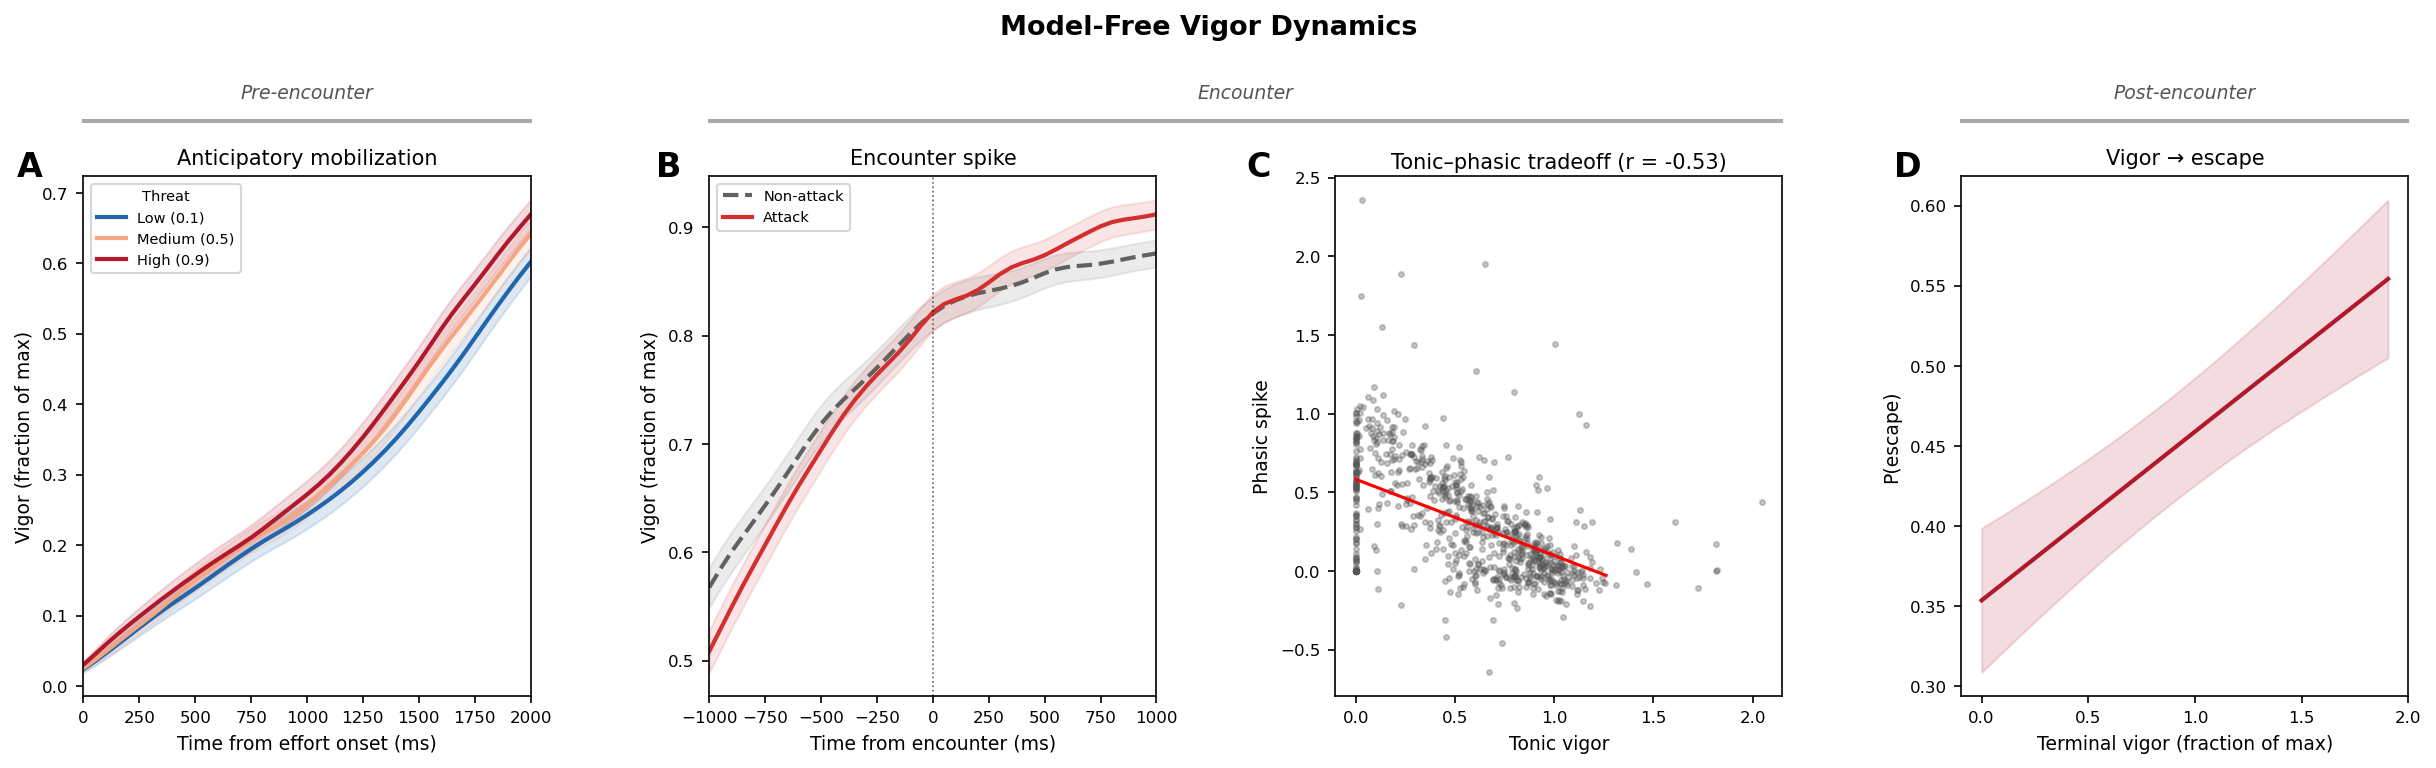

Saved → ../../figures/fig1_modelfree_vigor.png


In [35]:
# ── Figure 1: Model-Free Vigor Dynamics ───────────────────────────────────────
# Publication-ready version

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import pearsonr

FIGDIR = Path('../../figures')
FIGDIR.mkdir(exist_ok=True)

# ── Load smoothed vigor time series ──
ts = pd.read_parquet(DATA_PROC / 'smoothed_vigor_ts.parquet')

# Style constants
THREAT_COLORS = {0.1: '#2166ac', 0.5: '#f4a582', 0.9: '#b2182b'}
THREAT_LABELS = {0.1: 'Low (0.1)', 0.5: 'Medium (0.5)', 0.9: 'High (0.9)'}
S_TO_MS = 1000
PANEL_FONT = 16
TITLE_FONT = 10
LABEL_FONT = 9
TICK_FONT = 8


# ─────────────────────────────────────────────────────────────────────────────
# Helper: group PSTH with SEM
# ─────────────────────────────────────────────────────────────────────────────
def group_psth(df, time_col, value_col, group_col, t_min, t_max, dt=0.05):
    """Compute group-mean ± SEM on a common time grid."""
    n_dec = max(0, int(np.ceil(-np.log10(dt))))
    t_grid = np.round(np.arange(t_min, t_max + dt / 2, dt), n_dec)
    results = {}
    for grp, gdf in df.groupby(group_col):
        gdf = gdf.copy()
        gdf['t_bin'] = np.round(np.round(gdf[time_col] / dt) * dt, n_dec)
        gdf = gdf[(gdf['t_bin'] >= t_min) & (gdf['t_bin'] <= t_max)]
        subj_means = gdf.groupby(['subj', 't_bin'])[value_col].mean().reset_index()
        grand = subj_means.groupby('t_bin')[value_col].agg(['mean', 'sem']).reindex(t_grid)
        results[grp] = grand
    return t_grid, results


# ─────────────────────────────────────────────────────────────────────────────
# Build figure
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 4.5), dpi=150)
gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 1], wspace=0.40)

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL A — Pre-encounter: Anticipatory mobilization by threat
# ═══════════════════════════════════════════════════════════════════════════════
ax_a = fig.add_subplot(gs[0])

t_grid_a, psth_a = group_psth(ts, 't', 'vigor_norm', 'threat', t_min=0.0, t_max=2.0)

for thr in [0.1, 0.5, 0.9]:
    m = psth_a[thr]['mean'].values
    s = psth_a[thr]['sem'].values
    t_ms = t_grid_a * S_TO_MS
    ax_a.plot(t_ms, m, color=THREAT_COLORS[thr], lw=2, label=THREAT_LABELS[thr])
    ax_a.fill_between(t_ms, m - s, m + s, color=THREAT_COLORS[thr], alpha=0.15)

ax_a.set_xlabel('Time from effort onset (ms)', fontsize=LABEL_FONT)
ax_a.set_ylabel('Vigor (fraction of max)', fontsize=LABEL_FONT)
ax_a.set_title('Anticipatory mobilization', fontsize=TITLE_FONT)
ax_a.legend(title='Threat', fontsize=7, title_fontsize=7, loc='upper left')
ax_a.set_xlim(0, 2000)
ax_a.tick_params(labelsize=TICK_FONT)
ax_a.text(-0.15, 1.05, 'A', transform=ax_a.transAxes,
          fontsize=PANEL_FONT, fontweight='bold', va='top')

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL B — Encounter: Attack vs Non-attack spike
# ═══════════════════════════════════════════════════════════════════════════════
ax_b = fig.add_subplot(gs[1])

ts_enc = ts.dropna(subset=['encounterTime']).copy()
ts_enc['t_enc'] = ts_enc['t'] - ts_enc['encounterTime']

t_grid_b, psth_b = group_psth(
    ts_enc, 't_enc', 'vigor_norm', 'isAttackTrial', t_min=-1.0, t_max=1.0
)

attack_labels = {True: 'Attack', False: 'Non-attack', 1: 'Attack', 0: 'Non-attack'}
attack_colors = {True: '#d32f2f', False: '#616161', 1: '#d32f2f', 0: '#616161'}
attack_styles = {True: '-', False: '--', 1: '-', 0: '--'}

for atk in psth_b:
    m = psth_b[atk]['mean'].values
    s = psth_b[atk]['sem'].values
    t_ms = t_grid_b * S_TO_MS
    if np.all(np.isnan(m)):
        continue
    ax_b.plot(t_ms, m, color=attack_colors[atk], lw=2,
              ls=attack_styles[atk], label=attack_labels[atk])
    ax_b.fill_between(t_ms, m - s, m + s, color=attack_colors[atk], alpha=0.12)

ax_b.axvline(0, color='k', ls=':', lw=0.8, alpha=0.6)
ax_b.set_xlabel('Time from encounter (ms)', fontsize=LABEL_FONT)
ax_b.set_ylabel('Vigor (fraction of max)', fontsize=LABEL_FONT)
ax_b.set_title('Encounter spike', fontsize=TITLE_FONT)
ax_b.legend(fontsize=7, loc='upper left')
ax_b.set_xlim(-1000, 1000)
ax_b.tick_params(labelsize=TICK_FONT)
ax_b.text(-0.12, 1.05, 'B', transform=ax_b.transAxes,
          fontsize=PANEL_FONT, fontweight='bold', va='top')

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL C — Encounter: Tonic–phasic tradeoff
# ═══════════════════════════════════════════════════════════════════════════════
ax_c = fig.add_subplot(gs[2])

valid_tp = df_attack.dropna(subset=['pre_encounter_vigor_norm', 'encounter_spike_norm'])
x_tp = valid_tp['pre_encounter_vigor_norm']
y_tp = valid_tp['encounter_spike_norm']

rng = np.random.RandomState(42)
idx = rng.choice(len(valid_tp), size=min(800, len(valid_tp)), replace=False)
ax_c.scatter(x_tp.iloc[idx], y_tp.iloc[idx],
             s=6, alpha=0.3, c='#555', rasterized=True)

m_tp, b_tp = np.polyfit(x_tp, y_tp, 1)
x_line = np.array([x_tp.quantile(0.02), x_tp.quantile(0.98)])
ax_c.plot(x_line, m_tp * x_line + b_tp, 'r-', lw=1.5)

r_tp, p_tp = pearsonr(x_tp, y_tp)
ax_c.set_xlabel('Tonic vigor', fontsize=LABEL_FONT)
ax_c.set_ylabel('Phasic spike', fontsize=LABEL_FONT)
ax_c.set_title(f'Tonic–phasic tradeoff (r = {r_tp:.2f})', fontsize=TITLE_FONT, pad=4)
ax_c.tick_params(labelsize=TICK_FONT)
ax_c.text(-0.20, 1.05, 'C', transform=ax_c.transAxes,
          fontsize=PANEL_FONT, fontweight='bold', va='top')

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL D — Post-encounter: Terminal vigor → P(escape)
# (Attack trials only — escape is undefined on non-attack trials)
# ═══════════════════════════════════════════════════════════════════════════════
ax_d = fig.add_subplot(gs[3])

valid = df_attack.dropna(subset=['terminal_mean_norm', 'escaped', 'startDistance_z']).copy()
valid['tmn_z'] = (valid['terminal_mean_norm'] - valid['terminal_mean_norm'].mean()) / valid['terminal_mean_norm'].std()

# Fit the LPM
res, info, fit = run_lmm('escaped ~ tmn_z + threat_c + startDistance_z + C(choice)', valid)

# Marginal prediction (covariates at mean = 0)
intercept = fit.fe_params['Intercept']
beta_vigor = fit.fe_params['tmn_z']
mu = valid['terminal_mean_norm'].mean()
sd = valid['terminal_mean_norm'].std()

z_grid = np.linspace(valid['tmn_z'].quantile(0.01),
                     valid['tmn_z'].quantile(0.99), 200)
y_hat = intercept + beta_vigor * z_grid
x_raw = z_grid * sd + mu

# Delta-method CI
vcov = fit.cov_params()
se_pred = np.sqrt(vcov.loc['Intercept', 'Intercept']
                  + z_grid**2 * vcov.loc['tmn_z', 'tmn_z']
                  + 2 * z_grid * vcov.loc['Intercept', 'tmn_z'])
ci_lo = y_hat - 1.96 * se_pred
ci_hi = y_hat + 1.96 * se_pred

y_hat = np.clip(y_hat, 0, 1)
ci_lo = np.clip(ci_lo, 0, 1)
ci_hi = np.clip(ci_hi, 0, 1)

ax_d.fill_between(x_raw, ci_lo, ci_hi, color='#b2182b', alpha=0.15)
ax_d.plot(x_raw, y_hat, color='#b2182b', lw=2)

ax_d.set_xlabel('Terminal vigor (fraction of max)', fontsize=LABEL_FONT)
ax_d.set_ylabel('P(escape)', fontsize=LABEL_FONT)
ax_d.set_title('Vigor → escape', fontsize=TITLE_FONT)
ax_d.tick_params(labelsize=TICK_FONT)
ax_d.text(-0.15, 1.05, 'D', transform=ax_d.transAxes,
          fontsize=PANEL_FONT, fontweight='bold', va='top')

# ── Layout ──
fig.suptitle('Model-Free Vigor Dynamics', fontsize=13, fontweight='bold', y=1.12)
plt.tight_layout()

# ═══════════════════════════════════════════════════════════════════════════════
# Phase labels — spanning bars above panels (must come after tight_layout)
# ═══════════════════════════════════════════════════════════════════════════════
pos_a = ax_a.get_position()
pos_b = ax_b.get_position()
pos_c = ax_c.get_position()
pos_d = ax_d.get_position()

label_y = 0.99
bar_y = 0.96
bar_h = 0.004

# Pre-encounter — over A
fig.text((pos_a.x0 + pos_a.x1) / 2, label_y, 'Pre-encounter',
         ha='center', va='bottom', fontsize=9, fontstyle='italic', color='#555')
fig.patches.append(plt.Rectangle(
    (pos_a.x0, bar_y), pos_a.x1 - pos_a.x0, bar_h,
    transform=fig.transFigure, color='#aaa', clip_on=False))

# Encounter — spanning B + C
fig.text((pos_b.x0 + pos_c.x1) / 2, label_y, 'Encounter',
         ha='center', va='bottom', fontsize=9, fontstyle='italic', color='#555')
fig.patches.append(plt.Rectangle(
    (pos_b.x0, bar_y), pos_c.x1 - pos_b.x0, bar_h,
    transform=fig.transFigure, color='#aaa', clip_on=False))

# Post-encounter — over D
fig.text((pos_d.x0 + pos_d.x1) / 2, label_y, 'Post-encounter',
         ha='center', va='bottom', fontsize=9, fontstyle='italic', color='#555')
fig.patches.append(plt.Rectangle(
    (pos_d.x0, bar_y), pos_d.x1 - pos_d.x0, bar_h,
    transform=fig.transFigure, color='#aaa', clip_on=False))

# ── Save ──
fig.savefig(FIGDIR / 'fig1_modelfree_vigor.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {FIGDIR / "fig1_modelfree_vigor.png"}')

---
## Step 1 Summary Table

Publication-formatted table of all model-free tests. Each row shows:
- The **claim** being tested
- The full **model specification**  
- The **key predictor** and its coefficient
- Both normalization streams side-by-side where applicable

In [36]:
# ── Collect all Step 1 results into a structured summary ──────────────────────

summary_rows = []

# ─── 1A: Onset slope ─────────────────────────────────────────────────────────
for stream in ['norm', 'resid']:
    res, info, _ = run_lmm(f'onset_slope_{stream} ~ threat_c + C(choice)', df_trial)
    r = res[res['predictor'] == 'threat_c'].iloc[0]
    summary_rows.append({
        'Step': '1A',
        'Claim': 'Threat scales anticipatory vigor',
        'Model': f'onset_slope_{stream} ~ threat_c + C(choice) + (1|subj)',
        'Sample': 'All trials',
        'Key predictor': 'threat_c',
        'Stream': stream,
        'beta': r['beta'], 'SE': r['se'], 'p': r['p'],
        'CI_lo': r['ci_lo'], 'CI_hi': r['ci_hi'],
        'N_obs': int(info['nobs']), 'N_subj': int(info['n_groups']),
    })

# ─── 1B: Encounter spike ─────────────────────────────────────────────────────
for stream in ['norm', 'resid']:
    # Spike ~ attack
    res, info, _ = run_lmm(
        f'encounter_spike_{stream} ~ attack_c + threat_c + C(choice)', df_trial)
    r = res[res['predictor'] == 'attack_c'].iloc[0]
    summary_rows.append({
        'Step': '1B',
        'Claim': 'Attack triggers phasic spike',
        'Model': f'encounter_spike_{stream} ~ attack_c + threat_c + C(choice) + (1|subj)',
        'Sample': 'All trials',
        'Key predictor': 'attack_c',
        'Stream': stream,
        'beta': r['beta'], 'SE': r['se'], 'p': r['p'],
        'CI_lo': r['ci_lo'], 'CI_hi': r['ci_hi'],
        'N_obs': int(info['nobs']), 'N_subj': int(info['n_groups']),
    })

# Manipulation check
for stream in ['norm', 'resid']:
    res_pre, info_pre, _ = run_lmm(
        f'pre_encounter_vigor_{stream} ~ attack_c + threat_c + C(choice)', df_trial)
    r_pre = res_pre[res_pre['predictor'] == 'attack_c'].iloc[0]
    summary_rows.append({
        'Step': '1B-check',
        'Claim': 'Manipulation check (expect n.s.)',
        'Model': f'pre_encounter_vigor_{stream} ~ attack_c + threat_c + C(choice) + (1|subj)',
        'Sample': 'All trials',
        'Key predictor': 'attack_c',
        'Stream': stream,
        'beta': r_pre['beta'], 'SE': r_pre['se'], 'p': r_pre['p'],
        'CI_lo': r_pre['ci_lo'], 'CI_hi': r_pre['ci_hi'],
        'N_obs': int(info_pre['nobs']), 'N_subj': int(info_pre['n_groups']),
    })

# Tonic-phasic correlation
for stream in ['norm', 'resid']:
    pre_col = f'pre_encounter_vigor_{stream}'
    spike_col = f'encounter_spike_{stream}'
    valid = df_attack.dropna(subset=[pre_col, spike_col])
    r_val, p_val = pearsonr(valid[pre_col], valid[spike_col])
    summary_rows.append({
        'Step': '1B-corr',
        'Claim': 'Tonic–phasic tradeoff',
        'Model': f'Pearson r(pre_encounter_vigor_{stream}, encounter_spike_{stream})',
        'Sample': 'Attack trials',
        'Key predictor': 'r',
        'Stream': stream,
        'beta': r_val, 'SE': np.nan, 'p': p_val,
        'CI_lo': np.nan, 'CI_hi': np.nan,
        'N_obs': int(len(valid)), 'N_subj': int(valid['subj'].nunique()),
    })

# ─── 1C: Terminal vigor → escape ─────────────────────────────────────────────
for stream in ['norm', 'resid']:
    dv = f'terminal_mean_{stream}'
    dv_z = f'{dv}_z'
    valid = df_attack.dropna(subset=[dv, 'escaped', 'startDistance_z']).copy()
    valid[dv_z] = (valid[dv] - valid[dv].mean()) / valid[dv].std()
    res, info, _ = run_lmm(
        f'escaped ~ {dv_z} + threat_c + startDistance_z + C(choice)', valid)
    r = res[res['predictor'] == dv_z].iloc[0]
    summary_rows.append({
        'Step': '1C',
        'Claim': 'Terminal vigor predicts escape',
        'Model': f'escaped ~ terminal_mean_{stream}_z + threat_c + startDistance_z + C(choice) + (1|subj)',
        'Sample': 'Attack trials',
        'Key predictor': f'terminal_mean_{stream}_z',
        'Stream': stream,
        'beta': r['beta'], 'SE': r['se'], 'p': r['p'],
        'CI_lo': r['ci_lo'], 'CI_hi': r['ci_hi'],
        'N_obs': int(info['nobs']), 'N_subj': int(info['n_groups']),
    })

summary_df = pd.DataFrame(summary_rows)

# Save raw version
summary_df.to_csv(RESULTS / 'step1_modelfree_results.csv', index=False)
print(f'Raw results saved → {RESULTS / "step1_modelfree_results.csv"}')
print(f'{len(summary_df)} rows collected.')

Raw results saved → ../../results/step1_modelfree_results.csv
10 rows collected.


In [37]:
# ── Publication-formatted Table S1 ────────────────────────────────────────────

from IPython.display import display, HTML

def fmt_p(p):
    if p < 0.001:  return '< .001'
    elif p < 0.01: return f'{p:.3f}'
    else:          return f'{p:.3f}'

def fmt_sig(p):
    if p < 0.001:  return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else:          return ''

def fmt_ci(lo, hi):
    if np.isnan(lo): return '—'
    return f'[{lo:.3f}, {hi:.3f}]'

def fmt_stat(row):
    """Format the key statistic depending on test type."""
    if row['Step'] == '1B-corr':
        return f'r = {row["beta"]:.3f}'
    else:
        return f'{row["beta"]:.3f}'

# Build formatted rows
pub_rows = []
for _, row in summary_df.iterrows():
    stream_label = 'Capacity-norm.' if row['Stream'] == 'norm' else 'Demand-resid.'
    
    pub_rows.append({
        'Claim': row['Claim'],
        'Model': row['Model'],
        'Sample': row['Sample'],
        'Stream': stream_label,
        'Coeff.': row['Key predictor'],
        'β / r': fmt_stat(row),
        'SE': f'{row["SE"]:.3f}' if not np.isnan(row['SE']) else '—',
        '95% CI': fmt_ci(row['CI_lo'], row['CI_hi']),
        'p': fmt_p(row['p']),
        '': fmt_sig(row['p']),
        'N_obs': f'{int(row["N_obs"]):,}',
        'N_subj': int(row['N_subj']),
    })

pub_df = pd.DataFrame(pub_rows)

# ── Build HTML table with row grouping ──
html = """
<style>
    .s1-table { border-collapse: collapse; font-size: 11px; font-family: 'Helvetica', sans-serif; }
    .s1-table th { background: #2c3e50; color: white; padding: 6px 10px; text-align: left; 
                   font-weight: 600; border-bottom: 2px solid #1a252f; }
    .s1-table td { padding: 5px 10px; border-bottom: 1px solid #e0e0e0; vertical-align: top; }
    .s1-table tr:hover { background: #f5f5f5; }
    .s1-table .group-header { background: #ecf0f1; font-weight: 700; font-size: 11px; }
    .s1-table .model-spec { font-family: 'Courier New', monospace; font-size: 10px; color: #555; }
    .s1-table .sig { color: #c0392b; font-weight: 700; }
    .s1-table .ns { color: #95a5a6; }
    .s1-table .stream-norm { color: #2c3e50; }
    .s1-table .stream-resid { color: #7f8c8d; font-style: italic; }
</style>
<table class="s1-table">
<thead>
    <tr>
        <th>Model</th>
        <th>Stream</th>
        <th>Key coeff.</th>
        <th style="text-align:right">β / r</th>
        <th style="text-align:right">SE</th>
        <th>95% CI</th>
        <th style="text-align:right">p</th>
        <th></th>
        <th style="text-align:right">N<sub>obs</sub></th>
        <th style="text-align:right">N<sub>subj</sub></th>
    </tr>
</thead>
<tbody>
"""

# Group by Step
step_order = ['1A', '1B', '1B-check', '1B-corr', '1C']
step_titles = {
    '1A':       '1A — Threat scales anticipatory vigor',
    '1B':       '1B — Attack triggers phasic spike',
    '1B-check': '1B — Manipulation check (pre-encounter vigor; expect n.s.)',
    '1B-corr':  '1B — Tonic–phasic tradeoff',
    '1C':       '1C — Terminal vigor predicts escape',
}

for step in step_order:
    mask = summary_df['Step'] == step
    if not mask.any():
        continue
    
    title = step_titles.get(step, step)
    html += f'<tr class="group-header"><td colspan="10">{title}</td></tr>\n'
    
    for idx in summary_df[mask].index:
        row = summary_df.loc[idx]
        pr = pub_rows[idx]
        
        stream_cls = 'stream-norm' if row['Stream'] == 'norm' else 'stream-resid'
        sig_cls = 'sig' if row['p'] < 0.05 else 'ns'
        sig_star = fmt_sig(row['p'])
        
        html += f"""<tr>
    <td class="model-spec">{pr['Model']}</td>
    <td class="{stream_cls}">{pr['Stream']}</td>
    <td>{pr['Coeff.']}</td>
    <td style="text-align:right"><b>{pr['β / r']}</b></td>
    <td style="text-align:right">{pr['SE']}</td>
    <td>{pr['95% CI']}</td>
    <td style="text-align:right" class="{sig_cls}">{pr['p']}</td>
    <td class="sig">{sig_star}</td>
    <td style="text-align:right">{pr['N_obs']}</td>
    <td style="text-align:right">{pr['N_subj']}</td>
</tr>\n"""

html += "</tbody></table>"

display(HTML(html))

print('\nTable S1: Model-free vigor results. All models include random intercept per subject.')
print('Capacity-norm. = vigor as fraction of calibrated max; Demand-resid. = capacity-normalized minus group-mean demand curve.')
print('Coefficients for 1B-corr are Pearson r (no SE/CI reported).')


Table S1: Model-free vigor results. All models include random intercept per subject.
Capacity-norm. = vigor as fraction of calibrated max; Demand-resid. = capacity-normalized minus group-mean demand curve.
Coefficients for 1B-corr are Pearson r (no SE/CI reported).
